# Bernoulli, hands-on

The simplest non-trivial distribution. We exercise the **three operations** we'll do with *every* distribution in this course ·

1. **Sample** · draw $Y \sim \text{Bernoulli}(p)$.
2. **Score** · compute $\log P(Y \mid p)$.
3. **Compose** · stack $N$ samples into a likelihood and minimise its negative log.

Once these three feel mechanical for Bernoulli, the same recipe carries over to Categorical, Normal, Beta, Laplace — every distribution we meet later.

**Companion to** Lecture 0 · slide *"Bernoulli · what we'd compute in code"*.


In [1]:
import torch
import torch.distributions as dist
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0)
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 11, "font.size": 10,
})
RUST, SLATE, SAGE = "#B85A3E", "#4A6670", "#7B9E89"


## 1 · Sample

`dist.Bernoulli(p)` makes a distribution **object**. `.sample(shape)` returns a tensor.


In [2]:
coin = dist.Bernoulli(probs=0.6)
print("mean       :", float(coin.mean))            # = p
print("variance   :", float(coin.variance))        # = p(1-p)
print("one sample :", float(coin.sample()))
print("ten samples:", coin.sample((10,)).tolist())


mean       : 0.6000000238418579
variance   : 0.23999999463558197
one sample : 1.0
ten samples: [0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0]


### Sanity check · empirical frequency → $p$

Drawing many samples should give frequency $\to p$ (law of large numbers).


In [3]:
N_grid = [10, 100, 1_000, 10_000, 100_000]
true_p = 0.6
print(f"{'N':>8}  {'empirical p_hat':>16}  {'|error|':>10}")
print(f"{'-' * 8}  {'-' * 16}  {'-' * 10}")
for N in N_grid:
    samples = coin.sample((N,))
    p_hat = samples.mean().item()
    print(f"{N:>8}  {p_hat:>16.4f}  {abs(p_hat - true_p):>10.4f}")


       N   empirical p_hat     |error|
--------  ----------------  ----------
      10            0.7000      0.1000
     100            0.6000      0.0000
    1000            0.6040      0.0040
   10000            0.5998      0.0002
  100000            0.5991      0.0009


Empirical frequency converges to $p = 0.6$. The error scales as $1/\sqrt{N}$ — central-limit-theorem style.

---

## 2 · Score

`coin.log_prob(y)` evaluates the **compact form** $\log p^y (1-p)^{1-y}$ for us.


In [4]:
y_test = torch.tensor([0., 1.])
print("log p(Y=0 | p=0.6) =", float(coin.log_prob(y_test[0])), "→ exp =", float(torch.exp(coin.log_prob(y_test[0]))))
print("log p(Y=1 | p=0.6) =", float(coin.log_prob(y_test[1])), "→ exp =", float(torch.exp(coin.log_prob(y_test[1]))))


log p(Y=0 | p=0.6) = -0.916290819644928 → exp = 0.3999999761581421
log p(Y=1 | p=0.6) = -0.5108255743980408 → exp = 0.6000000238418579


Match the compact form ·

- $P(Y=0 \mid p) = 1 - p = 0.4$, so $\log P = \log 0.4 \approx -0.916$ ✓
- $P(Y=1 \mid p) = p = 0.6$, so $\log P = \log 0.6 \approx -0.511$ ✓

`log_prob` does both branches with **one formula**. That's the practical pay-off of the compact form.

---

## 3 · Compose · dataset log-likelihood and the MLE

Given $h$ heads in $N$ flips, the dataset log-likelihood is

$$\log P(\mathcal{D} \mid p) = h \log p + (N - h) \log(1 - p)$$

Plot it as a function of $p$ and find the peak — that's the **MLE**.


In [5]:
data = torch.tensor([1., 0., 1., 1., 0., 1., 0., 1., 1., 0.])   # 6 heads in 10 flips
N = len(data); h = int(data.sum().item())
print(f"data = {data.int().tolist()}   |   heads = {h}, N = {N}")

p_grid = torch.linspace(0.01, 0.99, 200)
loglik = torch.stack([dist.Bernoulli(p).log_prob(data).sum() for p in p_grid])

mle_idx = loglik.argmax()
p_mle = p_grid[mle_idx].item()
print(f"MLE from grid  = {p_mle:.3f}")
print(f"MLE analytical = h/N = {h / N:.3f}")


data = [1, 0, 1, 1, 0, 1, 0, 1, 1, 0]   |   heads = 6, N = 10
MLE from grid  = 0.601
MLE analytical = h/N = 0.600


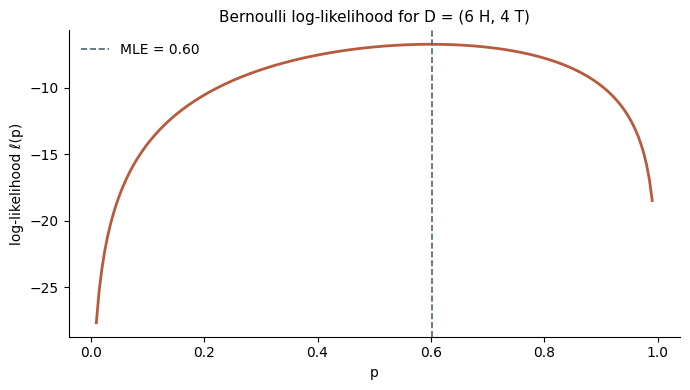

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(p_grid.numpy(), loglik.numpy(), color=RUST, lw=2)
ax.axvline(p_mle, color=SLATE, ls="--", lw=1.2, label=f"MLE = {p_mle:.2f}")
ax.set_xlabel("p"); ax.set_ylabel("log-likelihood ℓ(p)")
ax.set_title("Bernoulli log-likelihood for D = (6 H, 4 T)")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()


The peak is exactly at $h/N = 0.6$, matching the analytical answer derived on the slide. **The picture is the MLE.**

---

## 4 · BCE = NLL of Bernoulli

Pytorch's `BCELoss` is literally negative log-likelihood under a per-example Bernoulli. Show that ·

$$\text{BCE}(p, y) = -\log P(Y = y \mid p)$$

for any predicted probability $p$ and label $y$.


In [7]:
pred = torch.tensor([0.9, 0.2, 0.6, 0.05])
target = torch.tensor([1.0, 0.0, 1.0, 0.0])

# Manual NLL under Bernoulli
nll_manual = -dist.Bernoulli(probs=pred).log_prob(target)

# PyTorch's binary cross-entropy
bce_pytorch = torch.nn.functional.binary_cross_entropy(pred, target, reduction="none")

print("manual -log p (Bernoulli):", nll_manual.tolist())
print("F.binary_cross_entropy   :", bce_pytorch.tolist())
print("identical:", torch.allclose(nll_manual, bce_pytorch))


manual -log p (Bernoulli): [0.10536053776741028, 0.2231435775756836, 0.5108255743980408, 0.051293373107910156]
F.binary_cross_entropy   : [0.10536054521799088, 0.2231435477733612, 0.5108255743980408, 0.05129329487681389]
identical: True


**Identical, term by term.** Whenever you write `BCELoss()` in code, you are computing the *negative log-likelihood under a Bernoulli model*. That's the entire content of "loss = NLL of an assumed distribution" — and BCE is the simplest, most-used instance.

---

## 5 · IID factorisation · the product collapses

Stack $N$ Bernoulli flips. The product log-likelihood collapses to a function of just two counts $\#H, \#T$ — *no matter the order*.


In [8]:
N = 100; true_p = 0.7
flips = dist.Bernoulli(true_p).sample((N,))
shuffled = flips[torch.randperm(N)]

# log-likelihood at a candidate p, from the per-example product
def ll_from_product(y, p):
    return dist.Bernoulli(p).log_prob(y).sum().item()

# log-likelihood from the closed form using only the counts
def ll_from_counts(y, p):
    h = int(y.sum().item()); t = len(y) - h
    return h * np.log(p) + t * np.log(1 - p)

p_eval = 0.65
print(f"order-1: product = {ll_from_product(flips,    p_eval):.4f}")
print(f"order-2: product = {ll_from_product(shuffled, p_eval):.4f}")
print(f"closed-form counts only        = {ll_from_counts(flips, p_eval):.4f}")
print("→ order doesn't matter; only #H, #T do — the sufficient statistic.")


order-1: product = -61.6495
order-2: product = -61.6495
closed-form counts only        = -61.6495
→ order doesn't matter; only #H, #T do — the sufficient statistic.


All three numbers match · the order of the flips is irrelevant, only the head and tail *counts* are. That's why the MLE for Bernoulli has such a clean closed form.

---

## Try this

1. Set `pred = torch.tensor([0.5])` and compute `F.binary_cross_entropy(pred, torch.tensor([1.]))`. Verify it equals $\log 2 \approx 0.693$.
2. Plot the entropy $H(p) = -p \log p - (1-p) \log(1-p)$ vs $p$ on $[0, 1]$. Where does it peak, and why?
3. Use `dist.Bernoulli(logits=...)` instead of `probs=...`. What changes? (Hint · `logits = log(p / (1-p))`, exactly the logistic regression's pre-sigmoid output.)

---

## Takeaways

- **Sample · Score · Moments** — three operations · `dist.Bernoulli(p)` exposes all three.
- The compact form $p^y(1-p)^{1-y}$ lets `log_prob` handle both classes with one expression.
- **`BCELoss` *is* NLL of a Bernoulli.** Not "like" — *is*.
- The product over IID Bernoullis collapses to counts of heads + tails (a sufficient statistic).

Onward to **Categorical** — same three operations, $K$ outcomes instead of 2.
